In [10]:
df=pd.read_csv("no_ignition_with_weather_extended.csv")
df2 = df.rename({'temperature_2m': 'temperature', 'relative_humidity_2m': 'relative_humidity','windspeed_10m':'wind_speed','lat':'latitude','lon':'longitude'}, axis='columns')

In [13]:
df2.head()

,year,month,date,latitude,longitude,class,temperature,relative_humidity,wind_speed
1,2000,5,2000-05-15,53.876848,-116.055750,no_ignition,13.682500,45.240177,6.369050
2,2000,6,2000-06-15,56.715033,-113.130352,no_ignition,13.009001,48.900764,17.518356
3,2004,1,2004-01-15,50.268023,-117.718634,no_ignition,-2.040500,96.015892,4.320000
4,2004,4,2004-04-15,56.881581,-117.393642,no_ignition,-3.503500,55.214638,18.129137
5,2005,4,2005-04-15,49.359569,-110.719151,no_ignition,7.701500,34.509979,25.292400


In [12]:
df2=df2.iloc[1:]

In [14]:
df2.to_csv("non_igntion.csv",index=False)

In [23]:
import os
import re
import shutil
import pandas as pd
from pathlib import Path

def assign_split(year, month, scheme="train<=2019_val=2020_test>=2021"):
    ym = year * 100 + month
    if scheme == "train<=2018_val=2019_test>=2020":
        if ym <= 201812:
            return "train"
        if 201901 <= ym <= 201912:
            return "val"
        return "test"
    elif scheme == "train<=2019_val=2020_test>=2021":
        if ym <= 201912:
            return "train"
        if 202001 <= ym <= 202012:
            return "val"
        return "test"
    else:
        raise ValueError("unknown scheme")


def split_and_move_patches(patch_dir, scheme="train<=2019_val=2020_test>=2021", out_csv="patch_splits.csv"):
    """
    Scans a folder of patch .npz files, assigns train/val/test splits
    based on encoded YYYYMMDD date in filenames, and moves them into
    subfolders 'train', 'val', and 'test'.
    
    Expected filename format:
        patch_<patch_id>_ignition_<fire_number>_<YYYYMMDD>.npz
    """
    patch_dir = Path(patch_dir)
    if not patch_dir.exists():
        raise FileNotFoundError(f"{patch_dir} does not exist")

    patch_files = sorted(patch_dir.glob("patch_*.npz"))
    print(f"📦 Found {len(patch_files)} patches in {patch_dir}")

    # Create split folders
    split_dirs = {s: patch_dir / s for s in ["train", "val", "test"]}
    for d in split_dirs.values():
        d.mkdir(parents=True, exist_ok=True)

    # Regex for parsing filename
    pattern = re.compile(r"patch_(\d+)_(ignition|no_ignition)_([A-Za-z0-9]+)_(\d{8})\.npz")
    records = []

    for f in patch_files:
        name = f.name
        match = pattern.match(name)
        if not match:
            print(f"⚠️ Skipping invalid filename: {name}")
            continue

        patch_id,label, fire_num, date_str = match.groups()
        try:
            year = int(date_str[:4])
            month = int(date_str[4:6])
        except Exception as e:
            print(f"⚠️ Could not parse date in {name}: {e}")
            continue

        split = assign_split(year, month, scheme)
        target_dir = split_dirs[split]
        target_path = target_dir / name

        try:
            shutil.move(str(f), str(target_path))
        except Exception as e:
            print(f"⚠️ Failed to move {name}: {e}")
            continue

        records.append({
            "filename": name,
            "patch_id": int(patch_id),
            "fire_number": fire_num,
            "year": year,
            "month": month,
            "split": split,
            "new_path": str(target_path),
            "label":label
        })

        print(f"📁 {name} → {split}/")

    # --- Save summary CSV ---
    df = pd.DataFrame(records)
    out_path = patch_dir / out_csv
    df.to_csv(out_path, index=False)
    print(f"\n✅ Files moved successfully.")
    print(f"📄 Split summary saved to: {out_path}")
    print(df["split"].value_counts())
    return df


In [24]:
df_splits = split_and_move_patches(
    patch_dir="patches_25m_balanced",
    scheme="train<=2019_val=2020_test>=2021",
    out_csv="patch_splits.csv"
)


📦 Found 48737 patches in patches_25m_balanced
📁 patch_0_ignition_PWF001_20060402.npz → train/
📁 patch_10000_ignition_EWF064_20121017.npz → train/
📁 patch_10001_ignition_GWF075_20121024.npz → train/
📁 patch_10002_ignition_PWF002_20130419.npz → train/
📁 patch_10003_ignition_LWF028_20130506.npz → train/
📁 patch_10004_ignition_EWF019_20130310.npz → train/
📁 patch_10005_ignition_SWF030_20130514.npz → train/
📁 patch_10006_ignition_WWF006_20130506.npz → train/
📁 patch_10007_ignition_SWF002_20120409.npz → train/
📁 patch_10008_ignition_PWF025_20120201.npz → train/
📁 patch_10009_ignition_CWF014_20120506.npz → train/
📁 patch_1000_ignition_EWF054_20060516.npz → train/
📁 patch_10010_ignition_PWF023_20120201.npz → train/
📁 patch_10011_ignition_LWF053_20120512.npz → train/
📁 patch_10012_ignition_LWF054_20120512.npz → train/
📁 patch_10013_ignition_LWF055_20120512.npz → train/
📁 patch_10014_ignition_GWF021_20120514.npz → train/
📁 patch_10015_ignition_HWF078_20120528.npz → train/
📁 patch_10016_ignition_

In [28]:
import os
import numpy as np
import pandas as pd
from math import sin, cos, pi
from tqdm import tqdm

# --- CONFIG ---
patch_folder = "patches_25m_balanced/test"   # folder containing .npz patches
csv_path = "patches_25m_balanced/patch_splits.csv"            # CSV must have columns: filename, month
os.makedirs(patch_folder, exist_ok=True)

# --- Load month mapping ---
df = pd.read_csv(csv_path)
df.columns = [c.lower() for c in df.columns]
if "filename" not in df or "month" not in df:
    raise ValueError("CSV must have columns 'filename' and 'month'")

month_map = dict(zip(df["filename"], df["month"]))

# --- Iterate and update patches ---
for file in tqdm(os.listdir(patch_folder)):
    if not file.endswith(".npz"):
        continue

    if file not in month_map:
        print(f"⚠️ Skipping {file}: month not found in CSV")
        continue

    file_path = os.path.join(patch_folder, file)
    data = np.load(file_path)

    # --- Extract data ---
    if "class" not in data:
        raise KeyError(f"'class' key not found in {file}")

    y = data["class"]
    feature_keys = [k for k in data.keys() if k != "class"]

    # Use first feature to get patch shape
    H, W = data[feature_keys[0]].shape

    # --- Compute cyclical month encodings ---
    month = int(month_map[file])
    sin_m = sin(2 * pi * month / 12)
    cos_m = cos(2 * pi * month / 12)

    sin_month = np.full((H, W), sin_m, dtype=np.float32)
    cos_month = np.full((H, W), cos_m, dtype=np.float32)

    # --- Rebuild all keys ---
    out_dict = {}
    for key in feature_keys:
        out_dict[key] = data[key]
    out_dict["sin_month"] = sin_month
    out_dict["cos_month"] = cos_month
    out_dict["class"] = y

    # --- Overwrite file ---
    np.savez_compressed(file_path, **out_dict)

print("✅ Successfully added cyclical month encoding to all patches (overwritten, per-feature format).")


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7205/7205 [00:36<00:00, 198.75it/s]

✅ Successfully added cyclical month encoding to all patches (overwritten, per-feature format).


In [34]:
import pandas as pd

df = pd.read_csv("patches_25m_balanced/patch_splits.csv")  # ← update path if needed
df=df[df['split']=='val']
print("Total patches:", len(df))
print(df["label"].value_counts())
print("\nPercentage split:")
print(df["label"].value_counts(normalize=True) * 100)


Total patches: 1420
label
ignition       716
no_ignition    704
Name: count, dtype: int64

Percentage split:
label
ignition       50.422535
no_ignition    49.577465
Name: proportion, dtype: float64


In [7]:
TEST_FOLDER = "patches_25m_balanced/test"
LABEL_KEY = "class"
THRESHOLD = 0.45   # from your sweep

class NPZPatchDataset(Dataset):
    def __init__(self, folder, label_key="class", transforms=None, channel_stats=None):
        self.folder = folder
        self.files = sorted(glob.glob(os.path.join(folder, "patch_*.npz")))
        if len(self.files) == 0:
            raise FileNotFoundError(f"No patches found in {folder}")

        self.label_key = label_key
        self.transforms = transforms
        self.channel_stats = channel_stats
        self.skipped = []
        self.valid_files = []

        for f in self.files:
            try:
                arrs = np.load(f)
                if self.label_key in arrs.files:
                    self.valid_files.append(f)
                else:
                    self.skipped.append(os.path.basename(f))
            except Exception:
                self.skipped.append(os.path.basename(f))

        print(f"[TEST] valid={len(self.valid_files)}, skipped={len(self.skipped)}")

        arrs = np.load(self.valid_files[0])
        feature_keys = [k for k in arrs.files if k != self.label_key]
        self.C = len(feature_keys)

    def __len__(self):
        return len(self.valid_files)

    def __getitem__(self, idx):
        f = self.valid_files[idx]
        arrs = np.load(f)
        feature_keys = [k for k in arrs.files if k != self.label_key]

        X = np.stack([arrs[k] for k in feature_keys], axis=-1).astype(np.float32)
        # if X.shape[-1] > 2:
        #     X = X[..., :-2]     # keep all except last 2
        # else:
        #     raise ValueError("Dataset has fewer than 2 channels — cannot drop last two.")
        y = arrs[self.label_key].astype(np.float32)

        # normalize
        if self.channel_stats is not None:
            mean = self.channel_stats["mean"][:X.shape[-1]]
            std  = self.channel_stats["std"][:X.shape[-1]]
            X = (X - mean) / (std + 1e-6)

        if self.transforms:
            out = self.transforms(image=X, mask=y)
            X, y = out["image"], out["mask"]

        X = torch.from_numpy(X.transpose(2, 0, 1))  # (C,H,W)
        y = torch.from_numpy(y[None, ...])          # (1,H,W)
        return X, y, f   # also return file path for debugging

test_ds = NPZPatchDataset(TEST_FOLDER, label_key=LABEL_KEY,
                          transforms=None, channel_stats=stats)
print("Test patches:", len(test_ds))

H, W = test_ds[0][0].shape[1], test_ds[0][0].shape[2]
C = test_ds.C
print(f"Test patch shape: H={H}, W={W}, C={C}")


[TEST] valid=7205, skipped=0
Test patches: 7205
Test patch shape: H=64, W=64, C=17


In [5]:
def evaluate_dataset(model, dataset, threshold=0.35):
    total_tp = total_fp = total_tn = total_fn = 0
    patch_ign_total = patch_ign_detected = 0
    patch_neg_total = patch_neg_fp = 0

    for i in range(len(dataset)):
        X_t, y_t, fpath = dataset[i]
        X = X_t.numpy().transpose(1, 2, 0)       # (H,W,C)
        y = y_t.numpy()[0]                       # (H,W)

        # predict
        pred = model.predict(X[None, ...], verbose=0)[0, ..., 0]  # (H,W)

        y_bin = (y > 0.5).astype(np.float32)
        p_bin = (pred >= threshold).astype(np.float32)

        # pixel-level confusion
        total_tp += np.sum((p_bin == 1) & (y_bin == 1))
        total_fp += np.sum((p_bin == 1) & (y_bin == 0))
        total_tn += np.sum((p_bin == 0) & (y_bin == 0))
        total_fn += np.sum((p_bin == 0) & (y_bin == 1))

        # patch-level
        y_any = y_bin.max()
        p_any = p_bin.max()

        if y_any == 1:
            patch_ign_total += 1
            patch_ign_detected += int(p_any == 1)
        else:
            patch_neg_total += 1
            patch_neg_fp += int(p_any == 1)

    # pixel-level rates
    pixel_precision = total_tp / (total_tp + total_fp + 1e-7)
    pixel_recall    = total_tp / (total_tp + total_fn + 1e-7)
    pixel_fp_rate   = total_fp / (total_fp + total_tn + 1e-7)

    # patch-level
    patch_recall  = patch_ign_detected / (patch_ign_total + 1e-7)
    patch_fp_rate = patch_neg_fp / (patch_neg_total + 1e-7)

    metrics = {
        "pixel_precision": pixel_precision,
        "pixel_recall": pixel_recall,
        "pixel_fp_rate": pixel_fp_rate,
        "patch_ignition_recall": patch_recall,
        "patch_fp_rate": patch_fp_rate,
        "TP": int(total_tp),
        "FP": int(total_fp),
        "TN": int(total_tn),
        "FN": int(total_fn),
        "patch_ign_total": int(patch_ign_total),
        "patch_neg_total": int(patch_neg_total),
        "patch_neg_fp": int(patch_neg_fp),
    }
    return metrics

In [12]:
print("\n🔍 Evaluating on TEST set with threshold =", THRESHOLD)
test_metrics = evaluate_dataset(model, test_ds, threshold=THRESHOLD)

print("\n===== TEST METRICS =====")
for k, v in test_metrics.items():
    print(f"{k}: {v}")
print("========================\n")


🔍 Evaluating on TEST set with threshold = 0.45

===== TEST METRICS =====
pixel_precision: 0.07081001865127358
pixel_recall: 0.29299889745609153
pixel_fp_rate: 0.000472718429532385
patch_ignition_recall: 0.8949834619378451
patch_fp_rate: 0.19513558847651286
TP: 1063
FP: 13949
TN: 29494103
FN: 2565
patch_ign_total: 3628
patch_neg_total: 3577
patch_neg_fp: 698



In [8]:
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_opening, label

# ============================================================
# 1. Load Model A (ignition-only) & Model B (mixed-trained)
# ============================================================

MODEL_A_PATH = "deep_unet_focal_25m.h5"                 # <── replace if needed
MODEL_B_PATH = "deep_unet_focal_25m_p4.h5"    # <── your Phase-4 model

print("Loading Model A (ignition-only)…")
model_A = tf.keras.models.load_model(MODEL_A_PATH, compile=False)

print("Loading Model B (mixed-trained)…")
model_B = tf.keras.models.load_model(MODEL_B_PATH, compile=False)

print("Models loaded.")


# ============================================================
# 2. Two-stage prediction function
# ============================================================

def two_stage_predict(X_norm, threshold_B=0.35, threshold_A=0.35,
                      stats=None, clean=True, min_cc=0):
    """
    Stage 1: Model B decides if patch has ignition.
    Stage 2: If yes, Model A refines the spatial prediction.
    """

    # --- Stage 1: Patch-level decision ---
    pred_B = model_B.predict(X_norm[None, ...], verbose=0)[0, ..., 0]
    p_bin_B = (pred_B >= threshold_B).astype(np.float32)

    if p_bin_B.max() == 0:
        # B says: negative patch
        return pred_B, np.zeros_like(pred_B), "NEG_BY_B"

    # --- Stage 2: Spatial refinement ---
    pred_A = model_A.predict(X_norm[None, ...], verbose=0)[0, ..., 0]
    p_bin_A = (pred_A >= threshold_A).astype(np.float32)
    #print("max pred_A:", pred_A.max(), "min pred_A:", pred_A.min())
    # --- Optional cleaning ---
    if clean:
        p_bin_A = clean_mask(p_bin_A, min_cc=min_cc)

    return pred_A, p_bin_A, "POS_REFINED"


# ============================================================
# 3. Mask cleaning (to reduce FP noise)
# ============================================================

# def clean_mask(p_bin, morph_size=3, min_cc=3):
#     """
#     Remove tiny false blobs and isolated noise.
#     """
#     # Morphological opening
#     structure = np.ones((morph_size, morph_size))
#     opened = binary_opening(p_bin, structure=structure)

#     # Filter connected components by size
#     labeled, num = label(opened)
#     final = np.zeros_like(p_bin)

#     for i in range(1, num+1):
#         cc = (labeled == i)
#         if cc.sum() >= min_cc:
#             final[cc] = 1

#     return final
def clean_mask(p_bin, min_cc=10):
    labeled, num = label(p_bin)
    final = np.zeros_like(p_bin)
    for i in range(1, num+1):
        cc = (labeled == i)
        if cc.sum() >= min_cc:
            final[cc] = 1
    return final


# ============================================================
# 4. Evaluate two-stage model on test set
# ============================================================

def evaluate_two_stage(model_A, model_B, dataset,
                       threshold_B=0.35, threshold_A=0.35):

    total_tp = total_fp = total_tn = total_fn = 0
    patch_ign_total = patch_ign_detected = 0
    patch_neg_total = patch_neg_fp = 0

    for i in range(len(dataset)):
        X_t, y_t, fpath = dataset[i]
        X = X_t.numpy().transpose(1,2,0)
        y = y_t.numpy()[0]

        # ------------------------------------------------------------------
        # TWO-STAGE INFERENCE
        # ------------------------------------------------------------------
        _, p_bin, status = two_stage_predict(
            X,
            threshold_B=threshold_B,
            threshold_A=threshold_A,
            stats=stats,
            clean=True,
            min_cc=4
        )

        # pixel confusion
        y_bin = (y > 0.5).astype(np.float32)

        total_tp += np.sum((p_bin==1) & (y_bin==1))
        total_fp += np.sum((p_bin==1) & (y_bin==0))
        total_tn += np.sum((p_bin==0) & (y_bin==0))
        total_fn += np.sum((p_bin==0) & (y_bin==1))

        # patch-level confusion
        y_any = y_bin.max()
        p_any = p_bin.max()

        if y_any == 1:
            patch_ign_total += 1
            patch_ign_detected += int(p_any == 1)
        else:
            patch_neg_total += 1
            patch_neg_fp += int(p_any == 1)

    # ----------------------
    # FINAL METRICS
    # ----------------------
    metrics = {
        "pixel_precision": total_tp/(total_tp+total_fp+1e-7),
        "pixel_recall": total_tp/(total_tp+total_fn+1e-7),
        "pixel_fp_rate": total_fp/(total_fp+total_tn+1e-7),
        "patch_recall": patch_ign_detected/(patch_ign_total+1e-7),
        "patch_fp_rate": patch_neg_fp/(patch_neg_total+1e-7),
        "TP": int(total_tp),
        "FP": int(total_fp),
        "TN": int(total_tn),
        "FN": int(total_fn),
        "patch_ign_total": patch_ign_total,
        "patch_neg_total": patch_neg_total,
        "patch_neg_fp": patch_neg_fp
    }

    return metrics


# ============================================================
# 5. Visualization for refined model
# ============================================================

def visualize_two_stage(dataset, idx=0,
                        threshold_B=0.35, threshold_A=0.35):
    if idx is None:
        idx = random.randint(0, len(dataset)-1)

    X_t, y_t, fpath = dataset[idx]
    X = X_t.numpy().transpose(1,2,0)
    y = y_t.numpy()[0]

    # Stage A/B predictions
    pred_A, p_bin, status = two_stage_predict(
        X,
        threshold_B=threshold_B,
        threshold_A=threshold_A
    )

    rgb = X[..., :3]
    rgb = (rgb - rgb.min()) / (rgb.max() + 1e-7)

    fig, axs = plt.subplots(1,4,figsize=(18,4))

    axs[0].imshow(rgb)
    axs[0].set_title("Input Composite")
    axs[0].axis("off")

    axs[1].imshow(y, cmap="gray")
    axs[1].set_title("Ground Truth")
    axs[1].axis("off")

    axs[2].imshow(pred_A, cmap="inferno", vmin=0, vmax=1)
    axs[2].set_title("Model A Probabilities")
    axs[2].axis("off")

    axs[3].imshow(rgb, alpha=1.0)
    axs[3].imshow(p_bin, cmap="Reds", alpha=0.4)
    axs[3].set_title(f"Final Mask ({status})")
    axs[3].axis("off")

    fig.suptitle(os.path.basename(fpath), y=1.05)
    plt.tight_layout()
    plt.show()


# ============================================================
# 6. RUN ON TEST SET
# ============================================================

print("\n🔍 Evaluating Two-Stage Model A+B")

Loading Model A (ignition-only)…


I0000 00:00:1764457423.371976 4097681 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46277 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:01:00.0, compute capability: 8.6


Loading Model B (mixed-trained)…
Models loaded.

🔍 Evaluating Two-Stage Model A+B


In [14]:
two_stage_metrics = evaluate_two_stage(
    model_A, model_B,
    test_ds,
    threshold_B=0.25,
    threshold_A=0.30
)

In [15]:
print("\n===== TWO-STAGE TEST METRICS =====")
for k,v in two_stage_metrics.items():
    print(f"{k}: {v}")


===== TWO-STAGE TEST METRICS =====
pixel_precision: 0.19974354490761936
pixel_recall: 0.9445975743951324
pixel_fp_rate: 0.000465296726466388
patch_recall: 0.9448732083532284
patch_fp_rate: 0.23539278724530632
TP: 3427
FP: 13730
TN: 29494322
FN: 201
patch_ign_total: 3628
patch_neg_total: 3577
patch_neg_fp: 842


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_patch_output(
    dataset, idx,
    model_A, model_B,
    threshold_A=0.20,
    threshold_B=0.55,
    min_cc=4
):
    X_t, y_t, fpath = dataset[idx]
    X = X_t.numpy().transpose(1,2,0)   # (H,W,C)
    y = y_t.numpy()[0]                 # (H,W)

    # --------------------------
    # Stage 1: Model B decision
    # --------------------------
    pred_B = model_B.predict(X[None,...], verbose=0)[0,...,0]
    p_bin_B = (pred_B >= threshold_B).astype(np.float32)

    if p_bin_B.max() == 0:
        # Predicted negative patch
        pred_A = np.zeros_like(pred_B)
        refined_mask = np.zeros_like(pred_B)
        status = "NEG_BY_B"
    else:
        # --------------------------
        # Stage 2: Model A refinement
        # --------------------------
        pred_A = model_A.predict(X[None,...], verbose=0)[0,...,0]
        p_bin_A = (pred_A >= threshold_A).astype(np.float32)

        # --------------------------
        # Connected-component cleanup
        # --------------------------
        refined_mask = connected_component_clean(p_bin_A, min_cc=min_cc)
        status = "POS_REFINED"

    # --------------------------
    # Visualization starts here
    # --------------------------
    rgb = X[..., :3]
    rgb = (rgb - rgb.min()) / (rgb.max() + 1e-7)

    fig, axs = plt.subplots(1, 4, figsize=(20,5))

    # 1 — composite
    axs[0].imshow(rgb)
    axs[0].set_title("Input Composite")
    axs[0].axis("off")

    # 2 — ground truth
    axs[1].imshow(y, cmap="gray")
    axs[1].set_title("Ground Truth (Ignition Pixel)")
    axs[1].axis("off")

    # 3 — raw probability from Model A
    im = axs[2].imshow(pred_B, cmap="inferno", vmin=0, vmax=1)
    axs[2].set_title("Model A Probability Heatmap")
    axs[2].axis("off")
    fig.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04)

    # 4 — refined mask overlay
    axs[3].imshow(rgb, alpha=1)
    axs[3].imshow(pred_B, cmap="Reds", alpha=0.4)
    axs[3].set_title(f"Final Mask ({status})")
    axs[3].axis("off")

    fig.suptitle(f"{fpath}", y=1.05, fontsize=12)
    plt.tight_layout()
    plt.show()
from scipy.ndimage import label

def connected_component_clean(mask, min_cc=4):
    labeled, num = label(mask)
    final = np.zeros_like(mask)

    for cc in range(1, num+1):
        comp = (labeled == cc)
        if comp.sum() >= min_cc:
            final[comp] = 1
    return final


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.2932515].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.2932515].


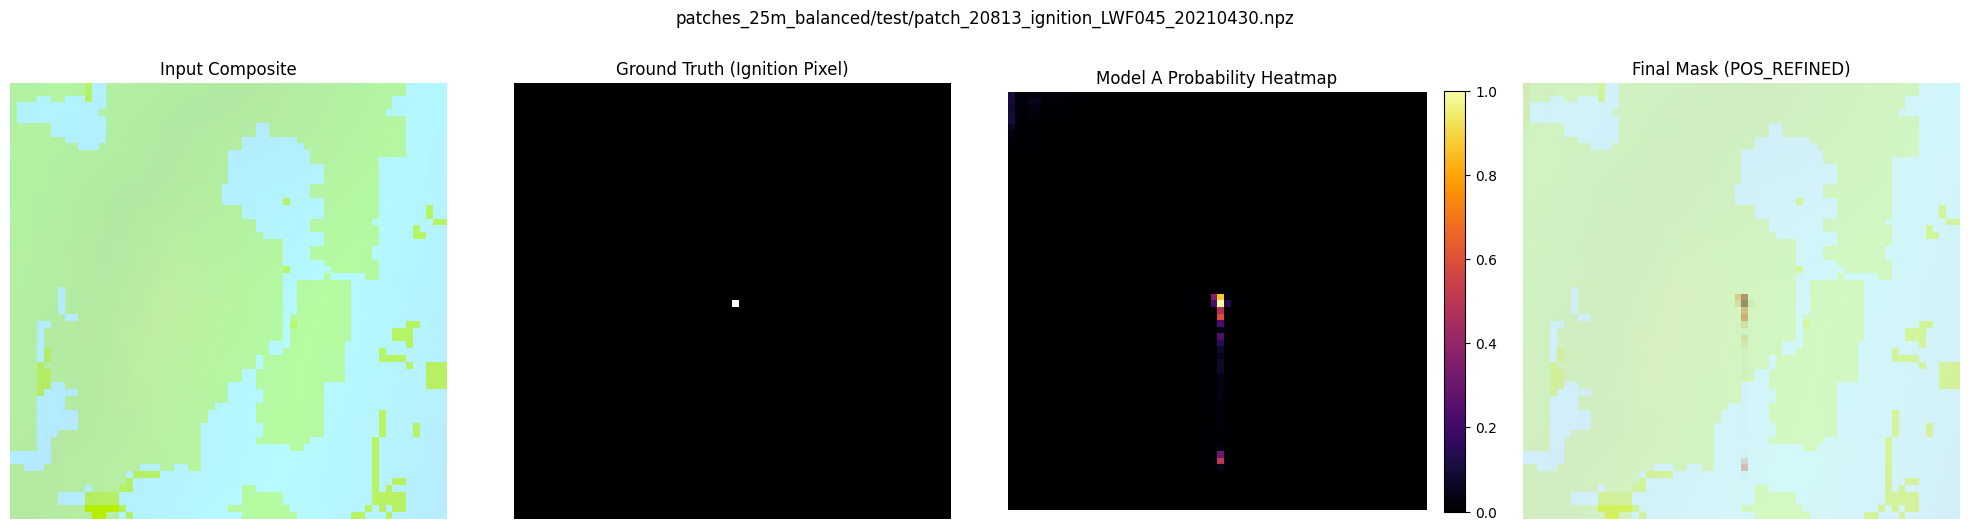

NameError: name 's' is not defined

In [13]:
visualize_patch_output(
    test_ds, idx=10,
    model_A=model_A, model_B=model_B,
    threshold_A=0.30,
    threshold_B=0.25,
    min_cc=4
)


In [75]:
def apply_gamma(img, gamma=0.1):
    """
    Apply gamma correction to a normalized 0–1 RGB image.
    img: float32 array in [0,1]
    gamma: typical values 1.6–2.2 for visualization
    """
    img = np.clip(img, 0, 1)
    return np.power(img, 1.0 / gamma)
def make_rgb_composite(X, gamma=1.8):
    """
    Create an RGB composite from first 3 channels of the patch,
    normalize each channel independently, and apply gamma correction.
    """
    rgb = X[..., :3]  # use first 3 channels
    rgb = rgb.astype(np.float32)

    # Normalize each channel to 0–1
    for i in range(3):
        c = rgb[..., i]
        rgb[..., i] = (c - c.min()) / (c.max() - c.min() + 1e-6)

    # Apply gamma correction
    rgb = apply_gamma(rgb, gamma=gamma)

    # Convert to 256×256 for folium basemap overlay
    rgb_uint8 = (rgb * 255).astype(np.uint8)
    rgb_big = np.array(Image.fromarray(rgb_uint8).resize((256, 256), Image.NEAREST))

    return rgb_big

def visualize_patch_two_stage_overlay(
    patch_path, stats, model_A, model_B,
    lat, lon,
    threshold_A=0.20, threshold_B=0.55,
    min_cc=4,
    gamma=1.8,
    output_html="patch_overlay.html"
):
    # ---------------------------
    # Load Patch
    # ---------------------------
    data = np.load(patch_path)
    X_keys = [k for k in data.files if k != "class"]
    X = np.stack([data[k] for k in X_keys], axis=-1).astype(np.float32)

    # Use only channels available in stats
    C = stats["mean"].shape[0]
    X = X[..., :C]
    H, W, _ = X.shape

    # ---------------------------
    # Normalize
    # ---------------------------
    X_norm = (X - stats["mean"][:C]) / (stats["std"][:C] + 1e-6)
    X_input = X_norm[None, ...]

    # ---------------------------
    # Stage 1 – Model B
    # ---------------------------
    pred_B = model_B.predict(X_input, verbose=0)[0, ..., 0]
    if pred_B.max() < threshold_B:
        final_mask = np.zeros((H, W))
    else:
        # ---------------------------
        # Stage 2 – Model A
        # ---------------------------
        pred_A = model_A.predict(X_input, verbose=0)[0, ..., 0]
        mask_A = (pred_A >= threshold_A).astype(np.float32)
        final_mask = connected_component_clean(mask_A, min_cc=min_cc)

    # ---------------------------
    # Make GAMMA-CORRECTED RGB
    # ---------------------------
    rgb_big = make_rgb_composite(X, gamma=gamma)

    # ---------------------------
    # Resize mask to 256×256
    # ---------------------------
    mask_img = (final_mask * 255).astype(np.uint8)
    mask_big = np.array(
        Image.fromarray(mask_img).resize((256,256), Image.NEAREST)
    )

    # Create RGBA overlay (mask)
    overlay_mask = np.zeros((256,256,4), dtype=np.uint8)
    overlay_mask[...,0] = mask_big      # red
    overlay_mask[...,3] = mask_big      # alpha

    # ---------------------------
    # Compute Geo Bounds
    # ---------------------------
    min_lat, max_lat, min_lon, max_lon = patch_extent(lat, lon, H, W, pixel_res_m=25)

    # ---------------------------
    # Folium Map
    # ---------------------------
    m = folium.Map(location=[lat, lon], zoom_start=12, tiles="OpenStreetMap")

    # # RGB composite overlay (light)
    # folium.raster_layers.ImageOverlay(
    #     image=rgb_big,
    #     bounds=[[min_lat, min_lon], [max_lat, max_lon]],
    #     opacity=0.8,
    #     name="RGB Patch"
    # ).add_to(m)

    # Mask overlay on top
    folium.raster_layers.ImageOverlay(
        image=overlay_mask,
        bounds=[[min_lat, min_lon], [max_lat, max_lon]],
        opacity=0.1,
        name="Ignition Mask"
    ).add_to(m)

    # Patch boundary box
    folium.Rectangle(
        bounds=[[min_lat, min_lon], [max_lat, max_lon]],
        color="black",
        weight=2,
        fill=False
    ).add_to(m)

    folium.LayerControl().add_to(m)
    m.save(output_html)
    return m



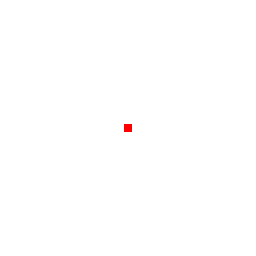

In [81]:
m = visualize_patch_two_stage_overlay(
    patch_path,
    stats,
    model_A=model_A,
    model_B=model_B,
    lat=lat, lon=lon,
    threshold_A=0.30,
    threshold_B=0.25,
    min_cc=4,
    gamma=1,
    output_html="patch_overlay.html"
)

m


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_npz_patch_plain(patch_path, max_channels=9):
    """
    Visualize a wildfire NPZ patch using only matplotlib.
    - Shows ignition mask
    - Shows up to 9 feature channels
    """
    data = np.load(patch_path)

    # Separate features and label
    y = data["class"]                          # (H,W)
    feature_keys = [k for k in data.files if k != "class"]
    feature_arrs = [data[k] for k in feature_keys]

    X = np.stack(feature_arrs, axis=-1)        # (H,W,C)
    H, W, C = X.shape

    print(f"Loaded: {patch_path}")
    print(f"Shape: {H}×{W}, Channels: {C}")
    print("Feature keys:", feature_keys)

    # Number of feature channels to display
    n_plot = min(C, 20)

    cols = 3
    rows = int(np.ceil((n_plot + 1) / cols))   # +1 for mask

    plt.figure(figsize=(14, 4 * rows))

    # ---- 1) Ground truth ignition mask ----
    ax = plt.subplot(rows, cols, 1)
    ax.imshow(y, cmap="gray")
    ax.set_title("Ignition Mask (Ground Truth)")
    ax.axis("off")

    # ---- 2…N) Feature channels ----
    for i in range(n_plot):
        ax = plt.subplot(rows, cols, i + 2)
        ax.imshow(X[..., i], cmap="viridis")
        ax.set_title(f"Feature: {feature_keys[i]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


Loaded: patches_25m/train/patch_10000_ignition_EWF064_20121017.npz
Shape: 64×64, Channels: 17
Feature keys: ['DEM_25m', 'distance_to_road', 'landcover_25m', 'municipalities_multiband_band1', 'municipalities_multiband_band2', 'municipalities_multiband_band3', 'municipalities_multiband_band4', 'municipalities_multiband_band5', 'municipalities_multiband_band6', 'municipalities_multiband_band7', 'municipalities_multiband_band8', 'water_25m', 'temperature', 'relative_humidity', 'wind_speed', 'sin_month', 'cos_month']


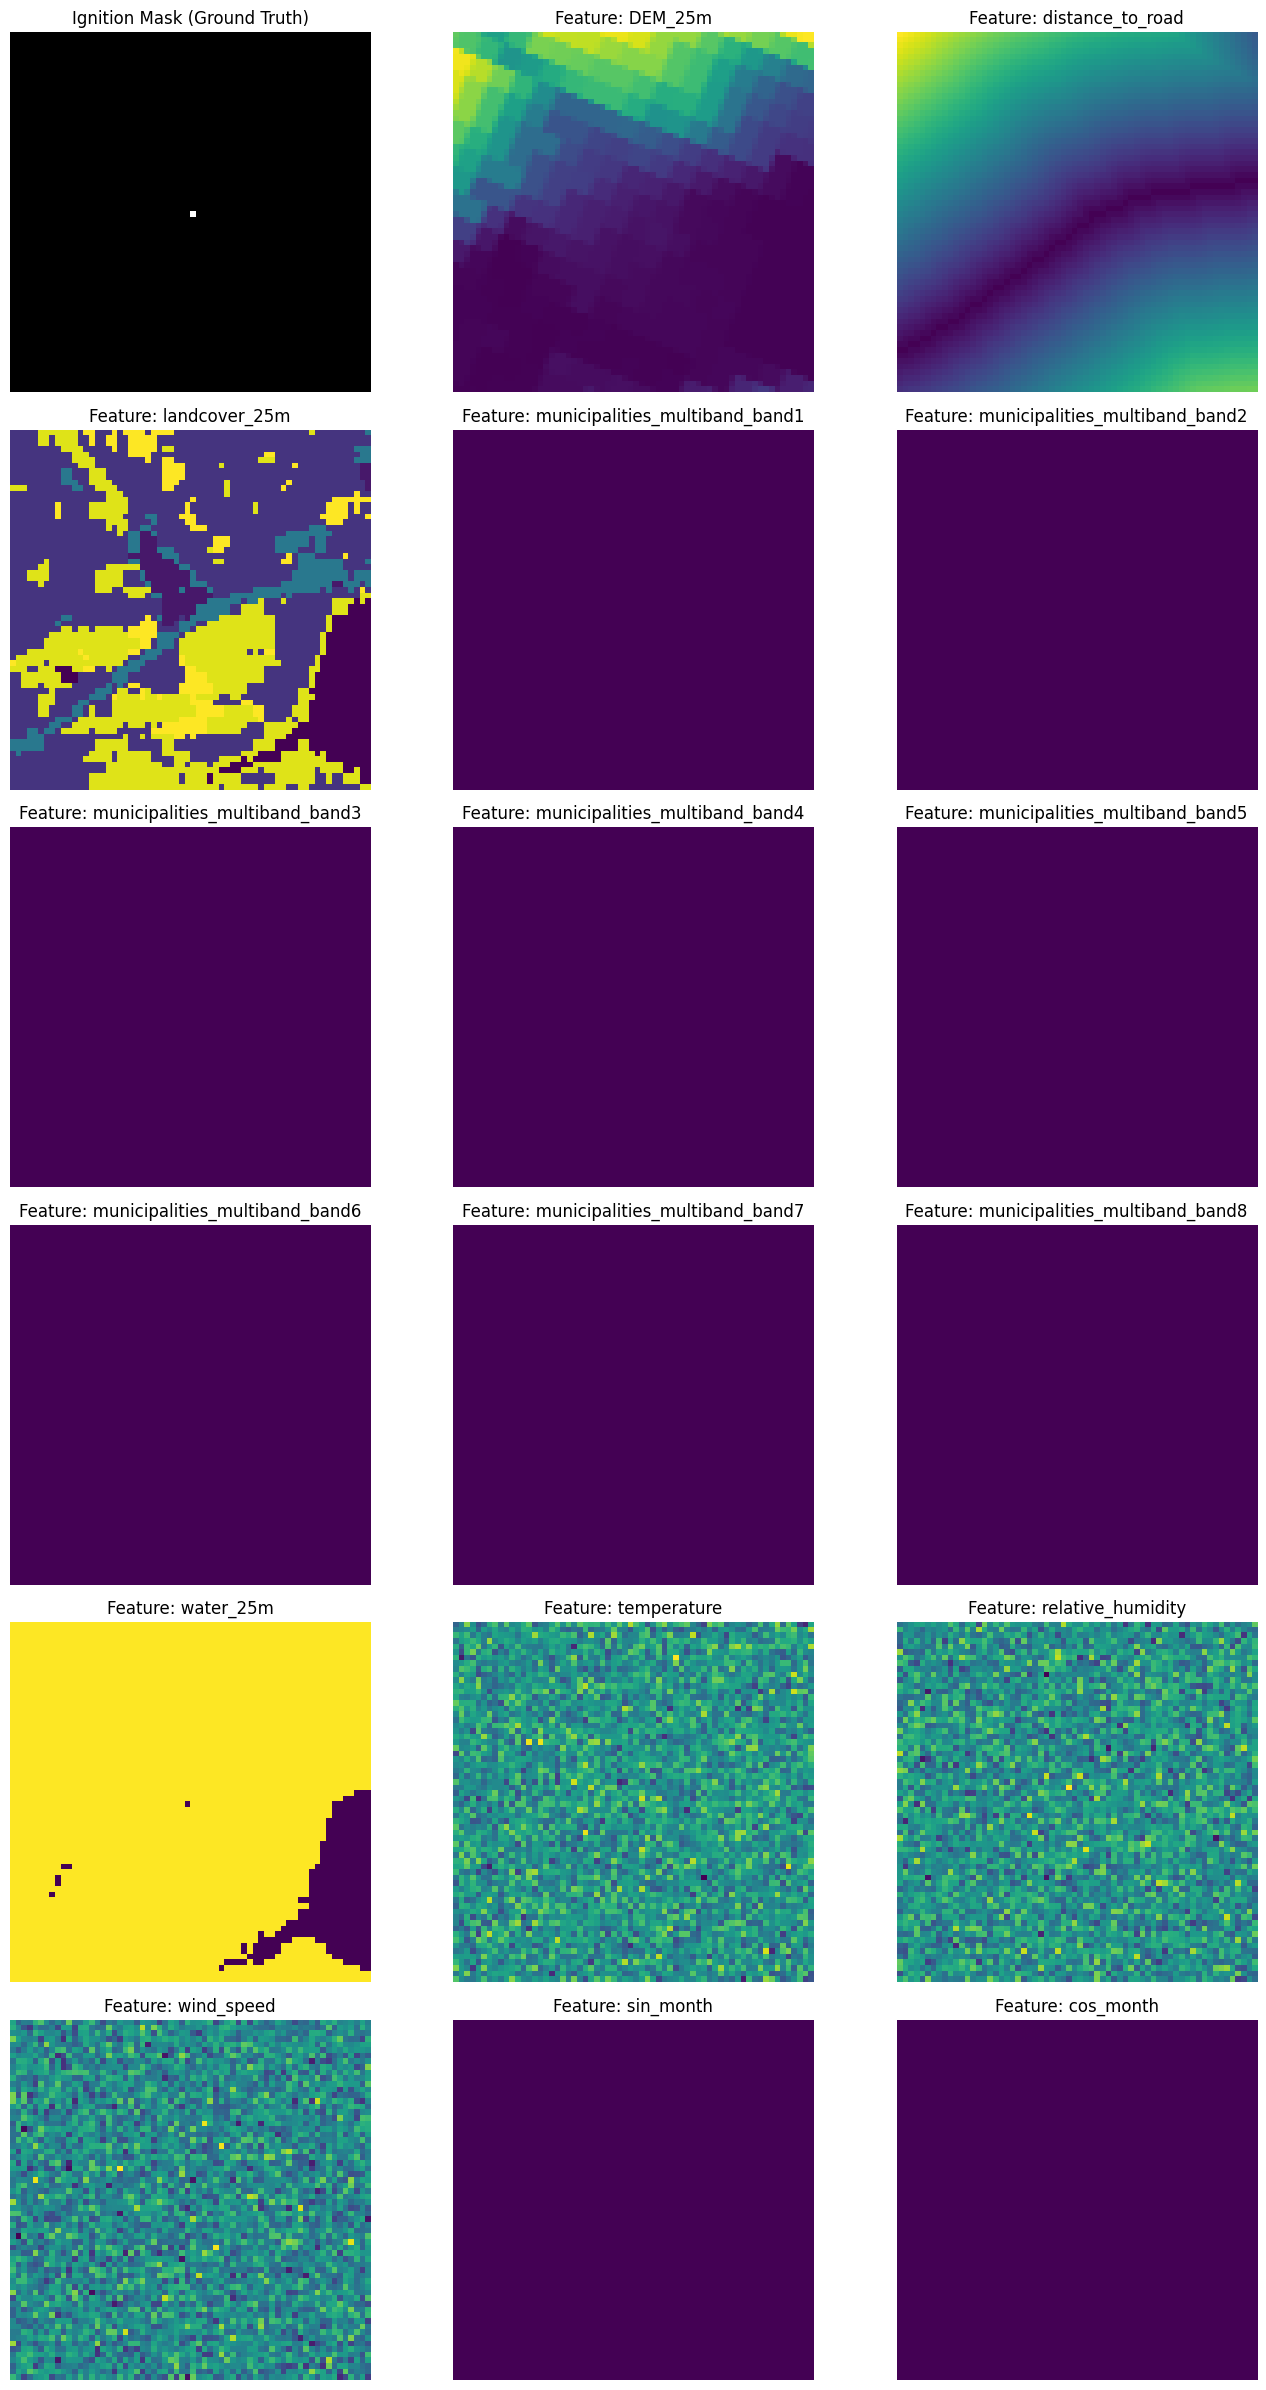

In [4]:
import glob

patch_files = sorted(glob.glob("patches_25m/train/patch_10000_ignition_EWF064_20121017.npz"))
visualize_npz_patch_plain(patch_files[0])


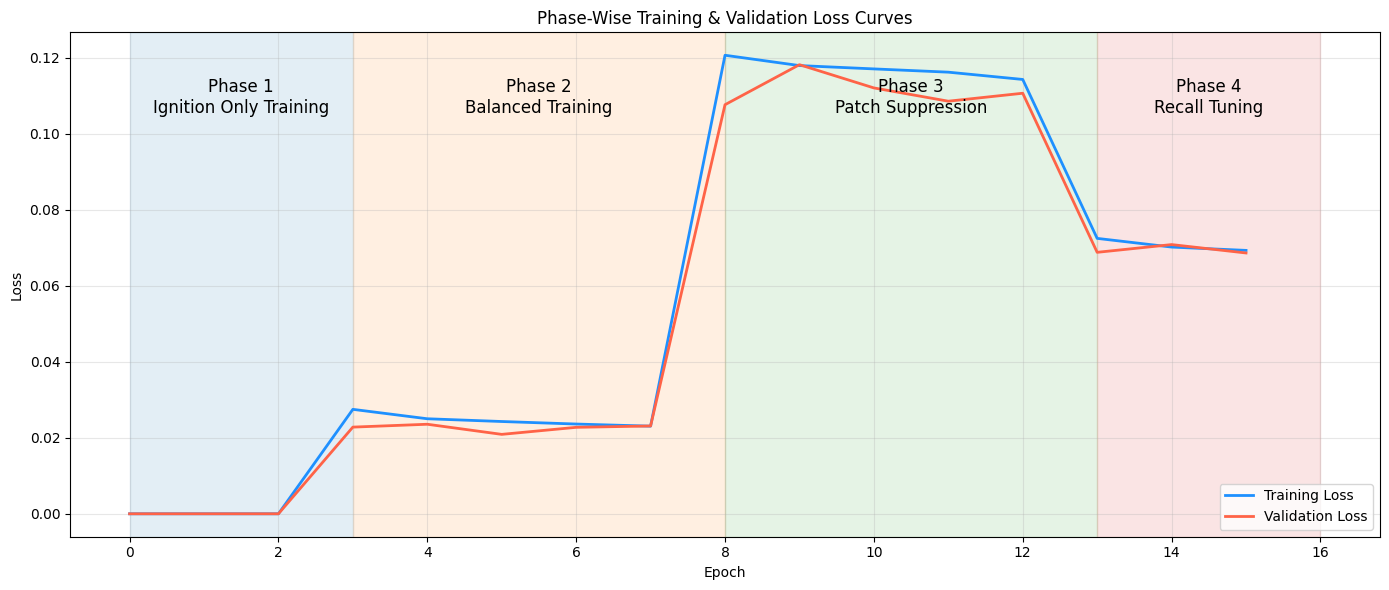

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Example history lists (replace with yours)
losses = (
    history_p1.history["loss"] +
    history_p2.history["loss"] +
    history_p3.history["loss"] +
    history_p4.history["loss"]
)

val_losses = (
    history_p1.history["val_loss"] +
    history_p2.history["val_loss"] +
    history_p3.history["val_loss"] +
    history_p4.history["val_loss"]
)

# Phase lengths
p1 = len(history_p1.history["loss"])
p2 = len(history_p2.history["loss"])
p3 = len(history_p3.history["loss"])
p4 = len(history_p4.history["loss"])

phase_boundaries = np.cumsum([p1, p2, p3, p4])

# ---- PLOT ----
plt.figure(figsize=(14,6))
epochs = np.arange(len(losses))

plt.plot(epochs, losses, label="Training Loss", color="dodgerblue", linewidth=2)
plt.plot(epochs, val_losses, label="Validation Loss", color="tomato", linewidth=2)

# ---- SHADED PHASE REGIONS ----
plt.axvspan(0, phase_boundaries[0], alpha=0.12, color="C0")
plt.axvspan(phase_boundaries[0], phase_boundaries[1], alpha=0.12, color="C1")
plt.axvspan(phase_boundaries[1], phase_boundaries[2], alpha=0.12, color="C2")
plt.axvspan(phase_boundaries[2], phase_boundaries[3], alpha=0.12, color="C3")

# ---- PHASE LABELS ----
plt.text(p1/2, max(losses)*0.95, "Phase 1\nIgnition Only Training", 
         ha="center", va="top", fontsize=12)
plt.text(p1 + p2/2, max(losses)*0.95, "Phase 2\nBalanced Training", 
         ha="center", va="top", fontsize=12)
plt.text(p1 + p2 + p3/2, max(losses)*0.95, "Phase 3\nPatch Suppression", 
         ha="center", va="top", fontsize=12)
plt.text(p1 + p2 + p3 + p4/2, max(losses)*0.95, "Phase 4\nRecall Tuning", 
         ha="center", va="top", fontsize=12)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Phase-Wise Training & Validation Loss Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
def extract_metrics(hist):
    """Extracts final precision, recall, pixel_fp, patch_fp from a Keras history."""
    precision = hist.history.get("precision")[-1] if "precision" in hist.history else None
    recall = hist.history.get("recall")[-1] if "recall" in hist.history else None

    # pixel-level FP (threshold 0.05 or similar)
    pixel_fp = hist.history.get("pixel_fp05", hist.history.get("pixel_fp", None))
    pixel_fp = pixel_fp[-1] if pixel_fp is not None else None

    # patch-level FP
    patch_fp = hist.history.get("patch_fp05", hist.history.get("patch_fp", None))
    patch_fp = patch_fp[-1] if patch_fp is not None else None

    return precision, recall, pixel_fp, patch_fp


In [12]:
m1 = extract_metrics(history_p1)
m2 = extract_metrics(history_p2)
m3 = extract_metrics(history_p3)
m4 = extract_metrics(history_p4)

metric_matrix = np.array([m1, m2, m3, m4])  


In [42]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_evolution(metric_matrix, metric_names=None, phase_names=None):
    """
    metric_matrix: shape (num_phases, num_metrics)
    metric_names: ["Precision", "Recall", "Pixel FP Rate", "Patch FP Rate"]
    phase_names: ["Phase 1", "Phase 2", "Phase 3", "Phase 4"]
    """

    

    if phase_names is None:
        phase_names = [f"Phase {i+1}" for i in range(metric_matrix.shape[0])]

    num_phases = metric_matrix.shape[0]
    num_metrics = metric_matrix.shape[1]

    x = np.arange(num_phases)
    width = 0.18  # bar width

    plt.figure(figsize=(14,6))

    for i in range(num_metrics):
        plt.bar(
            x + i*width,
            metric_matrix[:, i],
            width,
            label=metric_names[i],
            alpha=0.85
        )

    plt.xticks(x + width*(num_metrics-1)/2, phase_names, fontsize=12)
    plt.ylabel("Metric Value", fontsize=12)
    plt.title("Metric Evolution Across Training Phases", fontsize=14)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


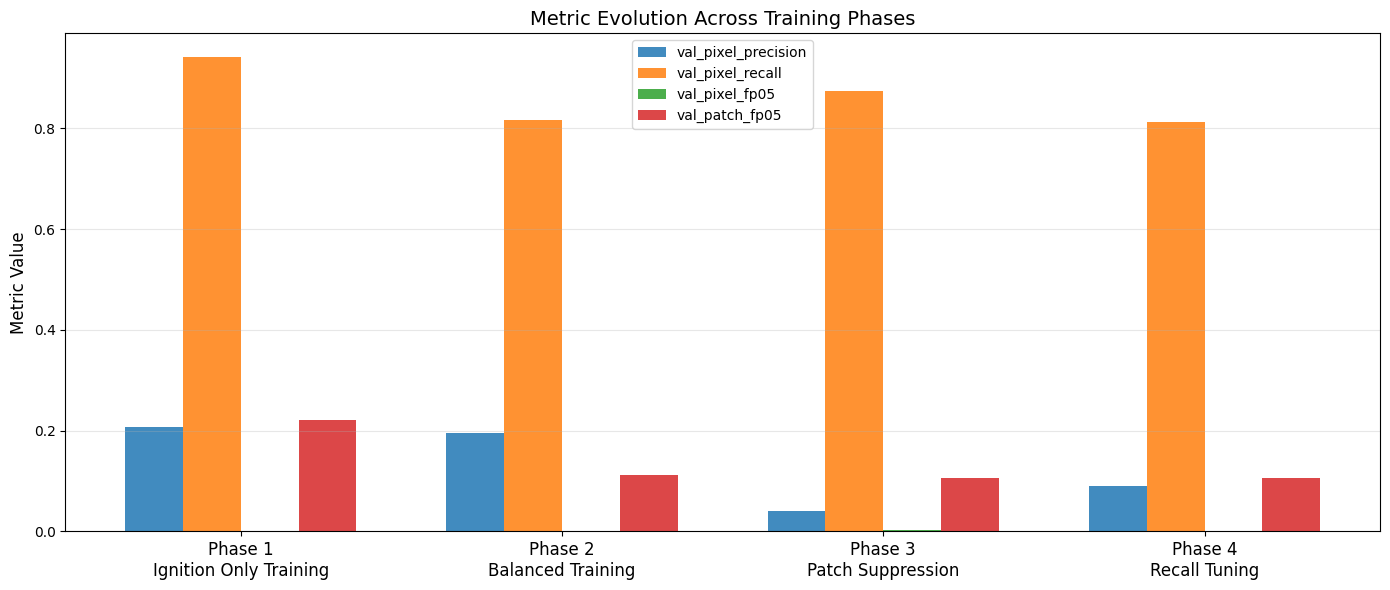

In [44]:
metric_names = ["val_pixel_precision", "val_pixel_recall", "val_pixel_fp05", "val_patch_fp05"]
phase_names  = ["Phase 1\nIgnition Only Training", "Phase 2\nBalanced Training", "Phase 3\nPatch Suppression", "Phase 4\nRecall Tuning"]

plot_metric_evolution(metric_matrix, metric_names, phase_names)


In [27]:
print(history_p1.history.keys())

dict_keys(['loss', 'patch_fp05', 'pixel_fp05', 'precision', 'recall', 'val_loss', 'val_patch_fp05', 'val_pixel_fp05', 'val_precision', 'val_recall'])
